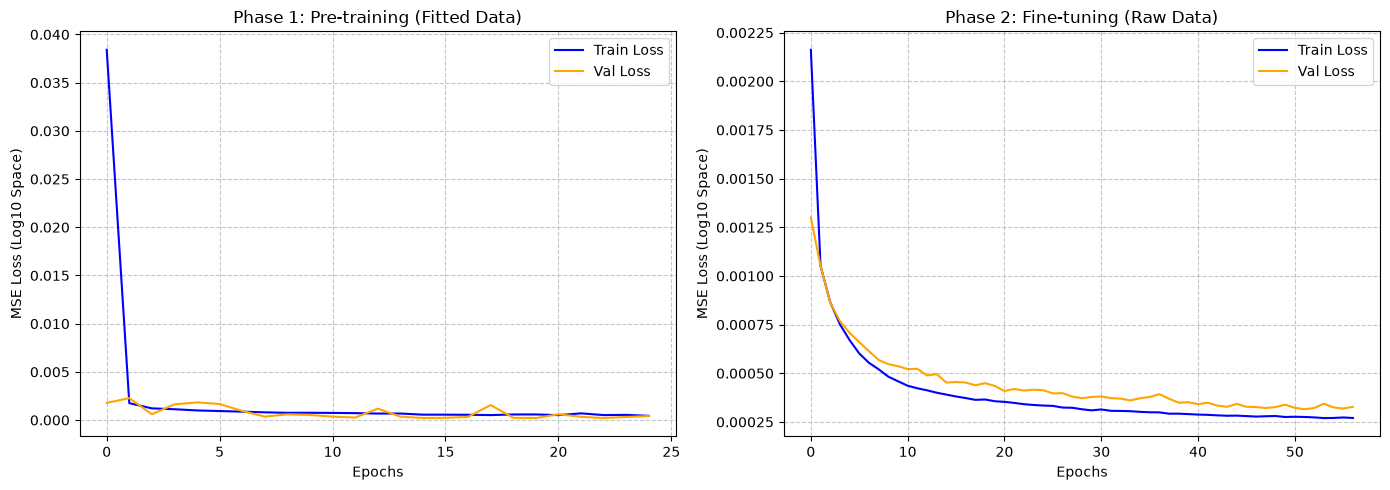

In [1]:
import joblib
import matplotlib.pyplot as plt

# Load the saved histories
history_fit = joblib.load('pretraining_history.joblib')
history_raw = joblib.load('fine_tuning_history.joblib')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Phase 1 (Fitted Data)
ax1.plot(history_fit['loss'], label='Train Loss', color='blue')
ax1.plot(history_fit['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Phase 1: Pre-training (Fitted Data)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MSE Loss (Log10 Space)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Phase 2 (Raw Data)
ax2.plot(history_raw['loss'], label='Train Loss', color='blue')
ax2.plot(history_raw['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Phase 2: Fine-tuning (Raw Data)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('MSE Loss (Log10 Space)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import pickle

train_test_data = np.load('train_test_data.npz')
scalerXraw = pickle.load(open('scalerXraw.pkl', 'rb'))
scaleryraw = pickle.load(open('scaleryraw.pkl', 'rb'))
scalerXfit = pickle.load(open('scalerXfit.pkl', 'rb'))
scaleryfit = pickle.load(open('scaleryfit.pkl', 'rb'))

Xraw_selected_train = train_test_data['Xraw_selected_train']
Xraw_selected_train_scaled = scalerXraw.transform(Xraw_selected_train)  
Xraw_selected_test = train_test_data['Xraw_selected_test']
Xraw_selected_test_scaled = scalerXraw.transform(Xraw_selected_test)

yraw_selected_train = train_test_data['yraw_selected_train']
yraw_selected_train_scaled = scaleryraw.transform(yraw_selected_train.reshape(-1, 1))
yraw_selected_test = train_test_data['yraw_selected_test']
yraw_selected_test_scaled = scaleryraw.transform(yraw_selected_test.reshape(-1, 1))

Xfit_selected_train = train_test_data['Xfit_selected_train']
Xfit_selected_train_scaled = scalerXfit.transform(Xfit_selected_train)
Xfit_selected_test = train_test_data['Xfit_selected_test']
Xfit_selected_test_scaled = scalerXfit.transform(Xfit_selected_test)    

yfit_selected_train = train_test_data['yfit_selected_train']
yfit_selected_train_scaled = scaleryfit.transform(yfit_selected_train.reshape(-1, 1))
yfit_selected_test = train_test_data['yfit_selected_test']
yfit_selected_test_scaled = scaleryfit.transform(yfit_selected_test.reshape(-1, 1)) 

Raw Min and Max j1 (Train): 0.0 16.0
Raw Min and Max j2 (Train): 0.0 23.0
Raw Min and Max j1  (Test): 0.0 16.0
Raw Min and Max j2  (Test): 0.0 23.0


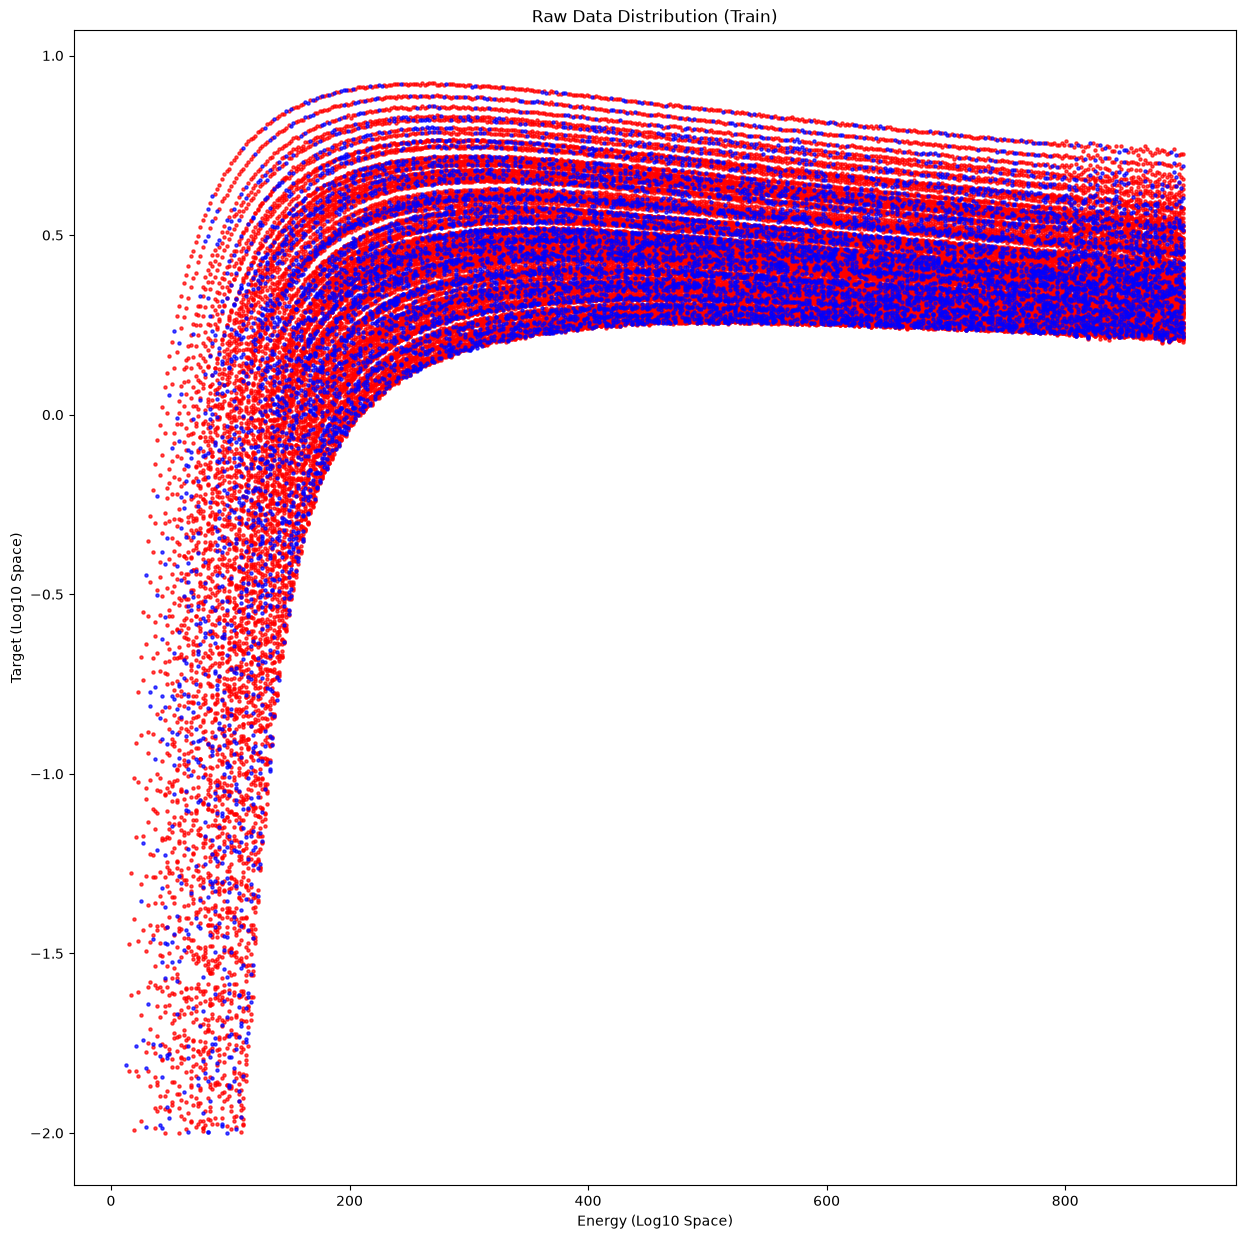

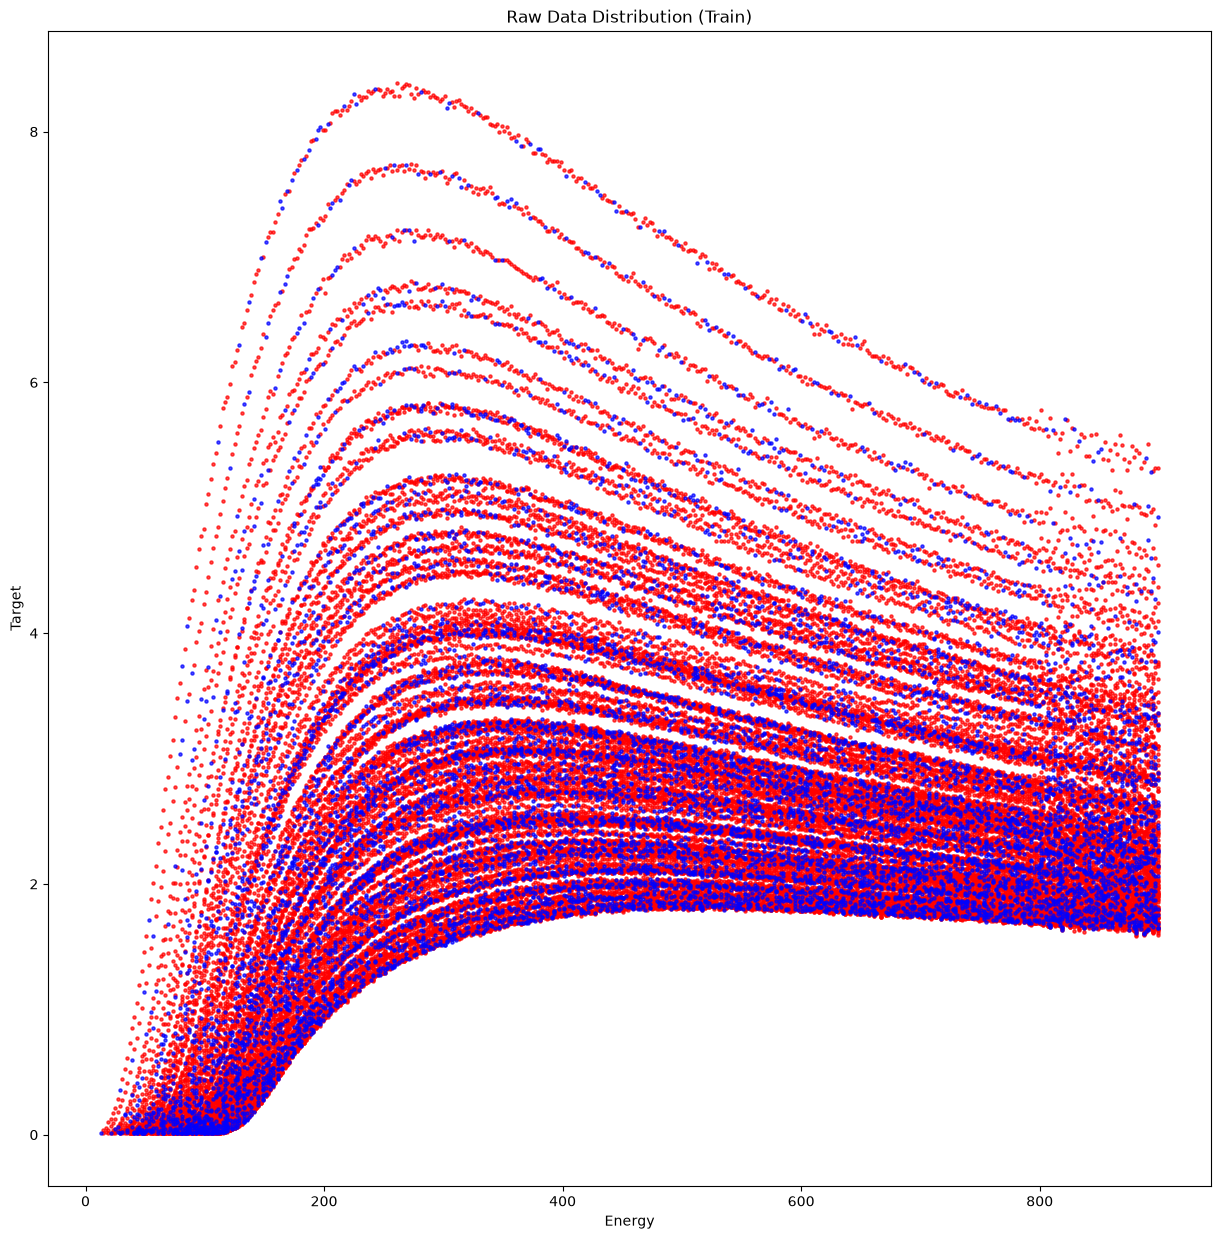

In [3]:
size=5
j1s_raw_train = Xraw_selected_train[:, 0]
j2s_raw_train = Xraw_selected_train[:, 1]
print("Raw Min and Max j1 (Train):", min(j1s_raw_train), max(j1s_raw_train))
print("Raw Min and Max j2 (Train):", min(j2s_raw_train), max(j2s_raw_train))
j1s_raw_test = Xraw_selected_test[:, 0]
j2s_raw_test = Xraw_selected_test[:, 1]
print("Raw Min and Max j1  (Test):", min(j1s_raw_test), max(j1s_raw_test))
print("Raw Min and Max j2  (Test):", min(j2s_raw_test), max(j2s_raw_test))   

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_raw_train):
    for j2 in np.unique(j2s_raw_train):
        selectedindex = np.where((Xraw_selected_train[:, 0] == j1) & (Xraw_selected_train[:, 1] == j2))
        Xraw_subset = Xraw_selected_train[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = yraw_selected_train[selectedindex]
        plt.scatter(eraw, yraw_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_raw_test):
    for j2 in np.unique(j2s_raw_test):
        selectedindex = np.where((Xraw_selected_test[:, 0] == j1) & (Xraw_selected_test[:, 1] == j2))
        Xraw_subset = Xraw_selected_test[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = yraw_selected_test[selectedindex]
        plt.scatter(eraw, yraw_subset, s=size, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy (Log10 Space)')
plt.ylabel('Target (Log10 Space)')
plt.title('Raw Data Distribution (Train)')
plt.show()

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_raw_train):
    for j2 in np.unique(j2s_raw_train):
        selectedindex = np.where((Xraw_selected_train[:, 0] == j1) & (Xraw_selected_train[:, 1] == j2))
        Xraw_subset = Xraw_selected_train[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = np.pow(10, yraw_selected_train[selectedindex])
        plt.scatter(eraw, yraw_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_raw_test):
    for j2 in np.unique(j2s_raw_test):
        selectedindex = np.where((Xraw_selected_test[:, 0] == j1) & (Xraw_selected_test[:, 1] == j2))
        Xraw_subset = Xraw_selected_test[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = np.pow(10, yraw_selected_test[selectedindex])
        plt.scatter(eraw, yraw_subset, s=size, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy')
plt.ylabel('Target')
plt.title('Raw Data Distribution (Train)')
plt.show()

Fitted Min and Max j1 (Train): 0.0 16.0
Fitted Min and Max j2 (Train): 0.0 23.0
Fitted Min and Max j1  (Test): 0.0 16.0
Fitted Min and Max j2  (Test): 0.0 23.0


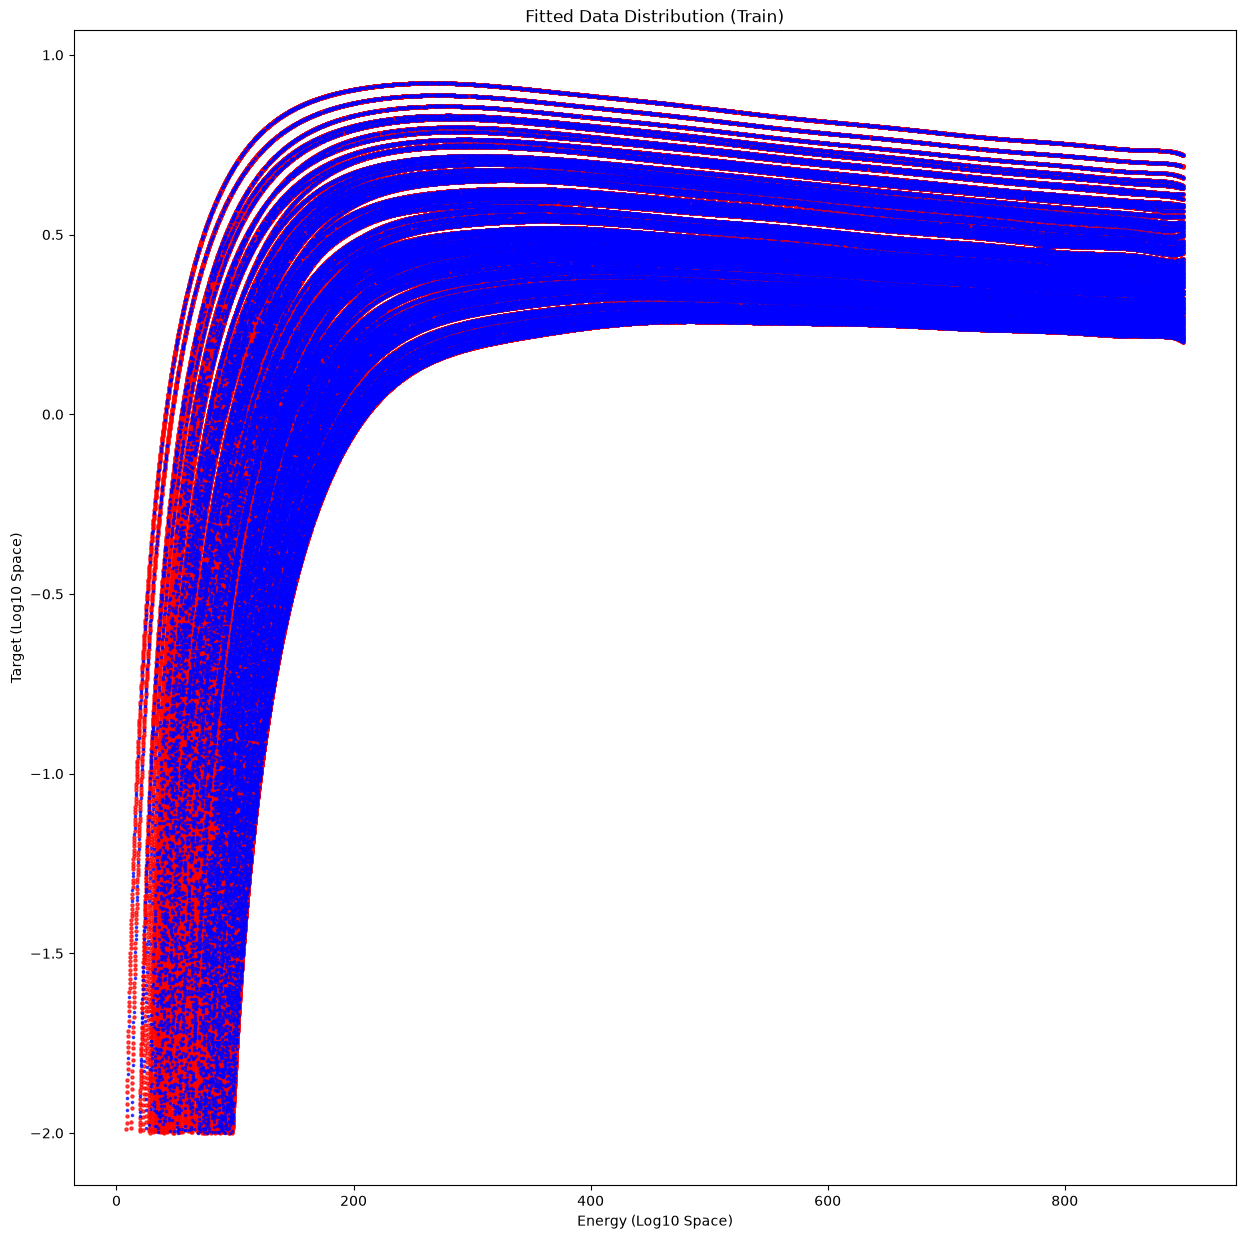

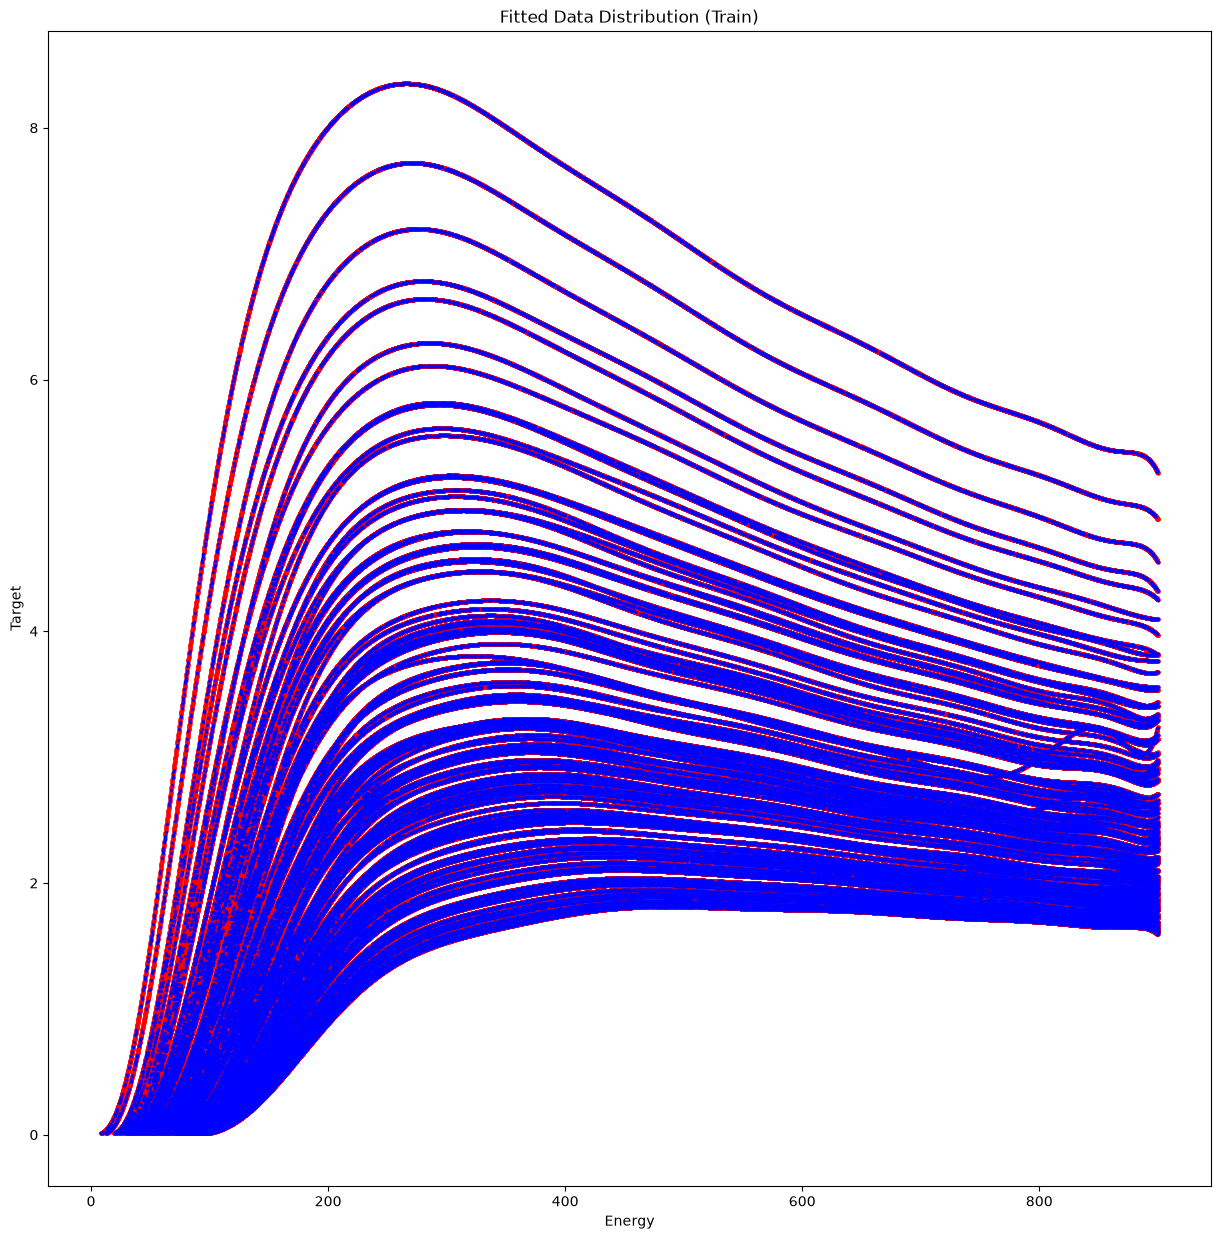

In [4]:
j1s_fit_train = Xfit_selected_train[:, 0]
j2s_fit_train = Xfit_selected_train[:, 1]
print("Fitted Min and Max j1 (Train):", min(j1s_fit_train), max(j1s_fit_train))
print("Fitted Min and Max j2 (Train):", min(j2s_fit_train), max(j2s_fit_train))
j1s_fit_test = Xfit_selected_test[:, 0]
j2s_fit_test = Xfit_selected_test[:, 1]
print("Fitted Min and Max j1  (Test):", min(j1s_fit_test), max(j1s_fit_test))
print("Fitted Min and Max j2  (Test):", min(j2s_fit_test), max(j2s_fit_test))

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_fit_train):
    for j2 in np.unique(j2s_fit_train):
        selectedindex = np.where((Xfit_selected_train[:, 0] == j1) & (Xfit_selected_train[:, 1] == j2))
        Xfit_subset = Xfit_selected_train[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = yfit_selected_train[selectedindex]
        plt.scatter(efit, yfit_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_fit_test):
    for j2 in np.unique(j2s_fit_test):
        selectedindex = np.where((Xfit_selected_test[:, 0] == j1) & (Xfit_selected_test[:, 1] == j2))
        Xfit_subset = Xfit_selected_test[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = yfit_selected_test[selectedindex]
        plt.scatter(efit, yfit_subset, s=size/2, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy (Log10 Space)')
plt.ylabel('Target (Log10 Space)')  
plt.title('Fitted Data Distribution (Train)')
plt.show()

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_fit_train):
    for j2 in np.unique(j2s_fit_train):
        selectedindex = np.where((Xfit_selected_train[:, 0] == j1) & (Xfit_selected_train[:, 1] == j2))
        Xfit_subset = Xfit_selected_train[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = np.pow(10, yfit_selected_train[selectedindex])
        plt.scatter(efit, yfit_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_fit_test):
    for j2 in np.unique(j2s_fit_test):
        selectedindex = np.where((Xfit_selected_test[:, 0] == j1) & (Xfit_selected_test[:, 1] == j2))
        Xfit_subset = Xfit_selected_test[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = np.pow(10, yfit_selected_test[selectedindex])
        plt.scatter(efit, yfit_subset, s=size/2, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy')
plt.ylabel('Target')
plt.title('Fitted Data Distribution (Train)')
plt.show()  

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pretrained_model= joblib.load('pretrained_model.joblib')
print("Pre-trained model loaded successfully.")
print("Pre-trained model summary:")
pretrained_model.summary()

pretrained_predraw_scaled_test = pretrained_model.predict(Xraw_selected_test_scaled)
pretrained_predraw_scaled_train = pretrained_model.predict(Xraw_selected_train_scaled)
pretrained_predraw_test = scaleryraw.inverse_transform(\
    pretrained_predraw_scaled_test.reshape(-1, 1))
pretrained_predraw_train = scaleryraw.inverse_transform(\
    pretrained_predraw_scaled_train.reshape(-1, 1))
pretrained_rmseraw_train = np.sqrt(np.mean((yraw_selected_train - pretrained_predraw_train.flatten()) ** 2))
pretrained_rmseraw_test = np.sqrt(np.mean((yraw_selected_test - pretrained_predraw_test.flatten()) ** 2))
pretrained_maeraw_train = np.mean(np.abs(yraw_selected_train - pretrained_predraw_train.flatten()))
pretrained_maeraw_test = np.mean(np.abs(yraw_selected_test - pretrained_predraw_test.flatten()))
pretrained_r2raw_train = 1 - np.sum((yraw_selected_train - pretrained_predraw_train.flatten()) ** 2) \
    / np.sum((yraw_selected_train - np.mean(yraw_selected_train)) ** 2)
pretrained_r2raw_test = 1 - np.sum((yraw_selected_test - pretrained_predraw_test.flatten()) ** 2) \
    / np.sum((yraw_selected_test - np.mean(yraw_selected_test)) ** 2)

pretrained_predfit_scaled = pretrained_model.predict(Xfit_selected_test_scaled)
pretrained_predfit_test = scaleryfit.inverse_transform(pretrained_predfit_scaled.reshape(-1, 1))
pretrained_predfit_scaled_train = pretrained_model.predict(Xfit_selected_train_scaled)
pretrained_predfit_train = scaleryfit.inverse_transform(pretrained_predfit_scaled_train.reshape(-1,   1))
pretrained_rmsefit_train = np.sqrt(np.mean((yfit_selected_train - pretrained_predfit_train.flatten()) ** 2))
pretrained_rmsefit_test = np.sqrt(np.mean((yfit_selected_test - pretrained_predfit_test.flatten()) ** 2))
pretrained_maefit_train = np.mean(np.abs(yfit_selected_train - pretrained_predfit_train.flatten()))
pretrained_maefit_test = np.mean(np.abs(yfit_selected_test - pretrained_predfit_test.flatten()))
pretrained_r2fit_train = 1 - np.sum((yfit_selected_train - pretrained_predfit_train.flatten()) ** 2) \
    / np.sum((yfit_selected_train - np.mean(yfit_selected_train)) ** 2)
pretrained_r2fit_test = 1 - np.sum((yfit_selected_test - pretrained_predfit_test.flatten()) ** 2) \
    / np.sum((yfit_selected_test - np.mean(yfit_selected_test)) ** 2)


I0000 00:00:1791364840.882980 2698875 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791364840.914014 2698875 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791364841.618516 2698875 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Pre-trained model loaded successfully.
Pre-trained model summary:


W0000 00:00:1791364841.866619 2698875 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,445 (52.52 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,964 (35.02 KB)

337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step
1348/1348 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step
6780/6780 ━━━━━━━━━━━━━━━━━━━━ 2s 281us/step
27118/27118 ━━━━━━━━━━━━━━━━━━━━ 7s 262us/step


In [6]:
fine_tuned_model = joblib.load('fine_tuned_model.joblib')
print("Fine-tuned model loaded successfully.")
print("Fine-tuned model summary:")
fine_tuned_model.summary()

fine_tuned_predraw_scaled_test = fine_tuned_model.predict(Xraw_selected_test_scaled)
fine_tuned_predraw_test = scaleryraw.inverse_transform(fine_tuned_predraw_scaled_test.reshape(-1, 1))
fine_tuned_predraw_scaled_train = fine_tuned_model.predict(Xraw_selected_train_scaled)
fine_tuned_predraw_train = scaleryraw.inverse_transform(fine_tuned_predraw_scaled_train.reshape(-1, 1))   
fine_tuned_rmseraw_train = np.sqrt(np.mean((yraw_selected_train - fine_tuned_predraw_train.flatten()) ** 2))
fine_tuned_rmseraw_test = np.sqrt(np.mean((yraw_selected_test - fine_tuned_predraw_test.flatten()) ** 2))
fine_tuned_maeraw_train = np.mean(np.abs(yraw_selected_train - fine_tuned_predraw_train.flatten()))
fine_tuned_maeraw_test = np.mean(np.abs(yraw_selected_test - fine_tuned_predraw_test.flatten()))
fine_tuned_r2raw_train = 1 - np.sum((yraw_selected_train - fine_tuned_predraw_train.flatten()) ** 2) \
    / np.sum((yraw_selected_train - np.mean(yraw_selected_train)) ** 2)
fine_tuned_r2raw_test = 1 - np.sum((yraw_selected_test - fine_tuned_predraw_test.flatten()) ** 2) \
    / np.sum((yraw_selected_test - np.mean(yraw_selected_test)) ** 2)                                      

fine_tuned_predfit_scaled_test = fine_tuned_model.predict(Xfit_selected_test_scaled)
fine_tuned_predfit_test = scaleryfit.inverse_transform(fine_tuned_predfit_scaled_test.reshape(-1, 1))
fine_tuned_predfit_scaled_train = fine_tuned_model.predict(Xfit_selected_train_scaled)
fine_tuned_predfit_train = scaleryfit.inverse_transform(fine_tuned_predfit_scaled_train.reshape(-1, 1))
fine_tuned_rmsefit_train = np.sqrt(np.mean((yfit_selected_train - fine_tuned_predfit_train.flatten()) ** 2))
fine_tuned_rmsefit_test = np.sqrt(np.mean((yfit_selected_test - fine_tuned_predfit_test.flatten()) ** 2))
fine_tuned_maefit_train = np.mean(np.abs(yfit_selected_train - fine_tuned_predfit_train.flatten()))
fine_tuned_maefit_test = np.mean(np.abs(yfit_selected_test - fine_tuned_predfit_test.flatten()))
fine_tuned_r2fit_train = 1 - np.sum((yfit_selected_train - fine_tuned_predfit_train.flatten()) ** 2) \
    / np.sum((yfit_selected_train - np.mean(yfit_selected_train)) ** 2)
fine_tuned_r2fit_test = 1 - np.sum((yfit_selected_test - fine_tuned_predfit_test.flatten()) ** 2) \
    / np.sum((yfit_selected_test - np.mean(yfit_selected_test)) ** 2)


Fine-tuned model loaded successfully.
Fine-tuned model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,933 (50.52 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 8,452 (33.02 KB)

337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step
1348/1348 ━━━━━━━━━━━━━━━━━━━━ 0s 273us/step
6780/6780 ━━━━━━━━━━━━━━━━━━━━ 2s 253us/step
27118/27118 ━━━━━━━━━━━━━━━━━━━━ 7s 259us/step


In [7]:
print("Model Performance on Raw Data:")
print(f"Pretrained Train RMSE: {pretrained_rmseraw_train:.4f}, Test RMSE: {pretrained_rmseraw_test:.4f}")
print(f"Fine Tuned Train RMSE: {fine_tuned_rmseraw_train:.4f}, Test RMSE: {fine_tuned_rmseraw_test:.4f}")
print(f" Pretrained Train MAE: {pretrained_maeraw_train:.4f},  Test MAE: {pretrained_maeraw_test:.4f}")
print(f" Fine Tuned Train MAE: {fine_tuned_maeraw_train:.4f},  Test MAE: {fine_tuned_maeraw_test:.4f}")
print(f"  Pretrained Train R2: {pretrained_r2raw_train:.4f},   Test R2: {pretrained_r2raw_test:.4f}")
print(f"  Fine Tuned Train R2: {fine_tuned_r2raw_train:.4f},   Test R2: {fine_tuned_r2raw_test:.4f}")

print("Model Performance on Fitted Data:")
print(f"Pretrained Train RMSE: {pretrained_rmsefit_train:.4f}, Test RMSE: {pretrained_rmsefit_test:.4f}")
print(f"Fine Tuned Train RMSE: {fine_tuned_rmsefit_train:.4f}, Test RMSE: {fine_tuned_rmsefit_test:.4f}")
print(f" Pretrained Train MAE: {pretrained_maefit_train:.4f},  Test MAE: {pretrained_maefit_test:.4f}")
print(f" Fine Tuned Train MAE: {fine_tuned_maefit_train:.4f},  Test MAE: {fine_tuned_maefit_test:.4f}")
print(f"  Pretrained Train R2: {pretrained_r2fit_train:.4f},   Test R2: {pretrained_r2fit_test:.4f}")
print(f"  Fine Tuned Train R2: {fine_tuned_r2fit_train:.4f},   Test R2: {fine_tuned_r2fit_test:.4f}")   

Model Performance on Raw Data:
Pretrained Train RMSE: 0.0299, Test RMSE: 0.0297
Fine Tuned Train RMSE: 0.0060, Test RMSE: 0.0066
 Pretrained Train MAE: 0.0117,  Test MAE: 0.0116
 Fine Tuned Train MAE: 0.0036,  Test MAE: 0.0037
  Pretrained Train R2: 0.9935,   Test R2: 0.9933
  Fine Tuned Train R2: 0.9997,   Test R2: 0.9997
Model Performance on Fitted Data:
Pretrained Train RMSE: 0.0053, Test RMSE: 0.0053
Fine Tuned Train RMSE: 0.0318, Test RMSE: 0.0314
 Pretrained Train MAE: 0.0030,  Test MAE: 0.0030
 Fine Tuned Train MAE: 0.0111,  Test MAE: 0.0110
  Pretrained Train R2: 0.9998,   Test R2: 0.9998
  Fine Tuned Train R2: 0.9926,   Test R2: 0.9928


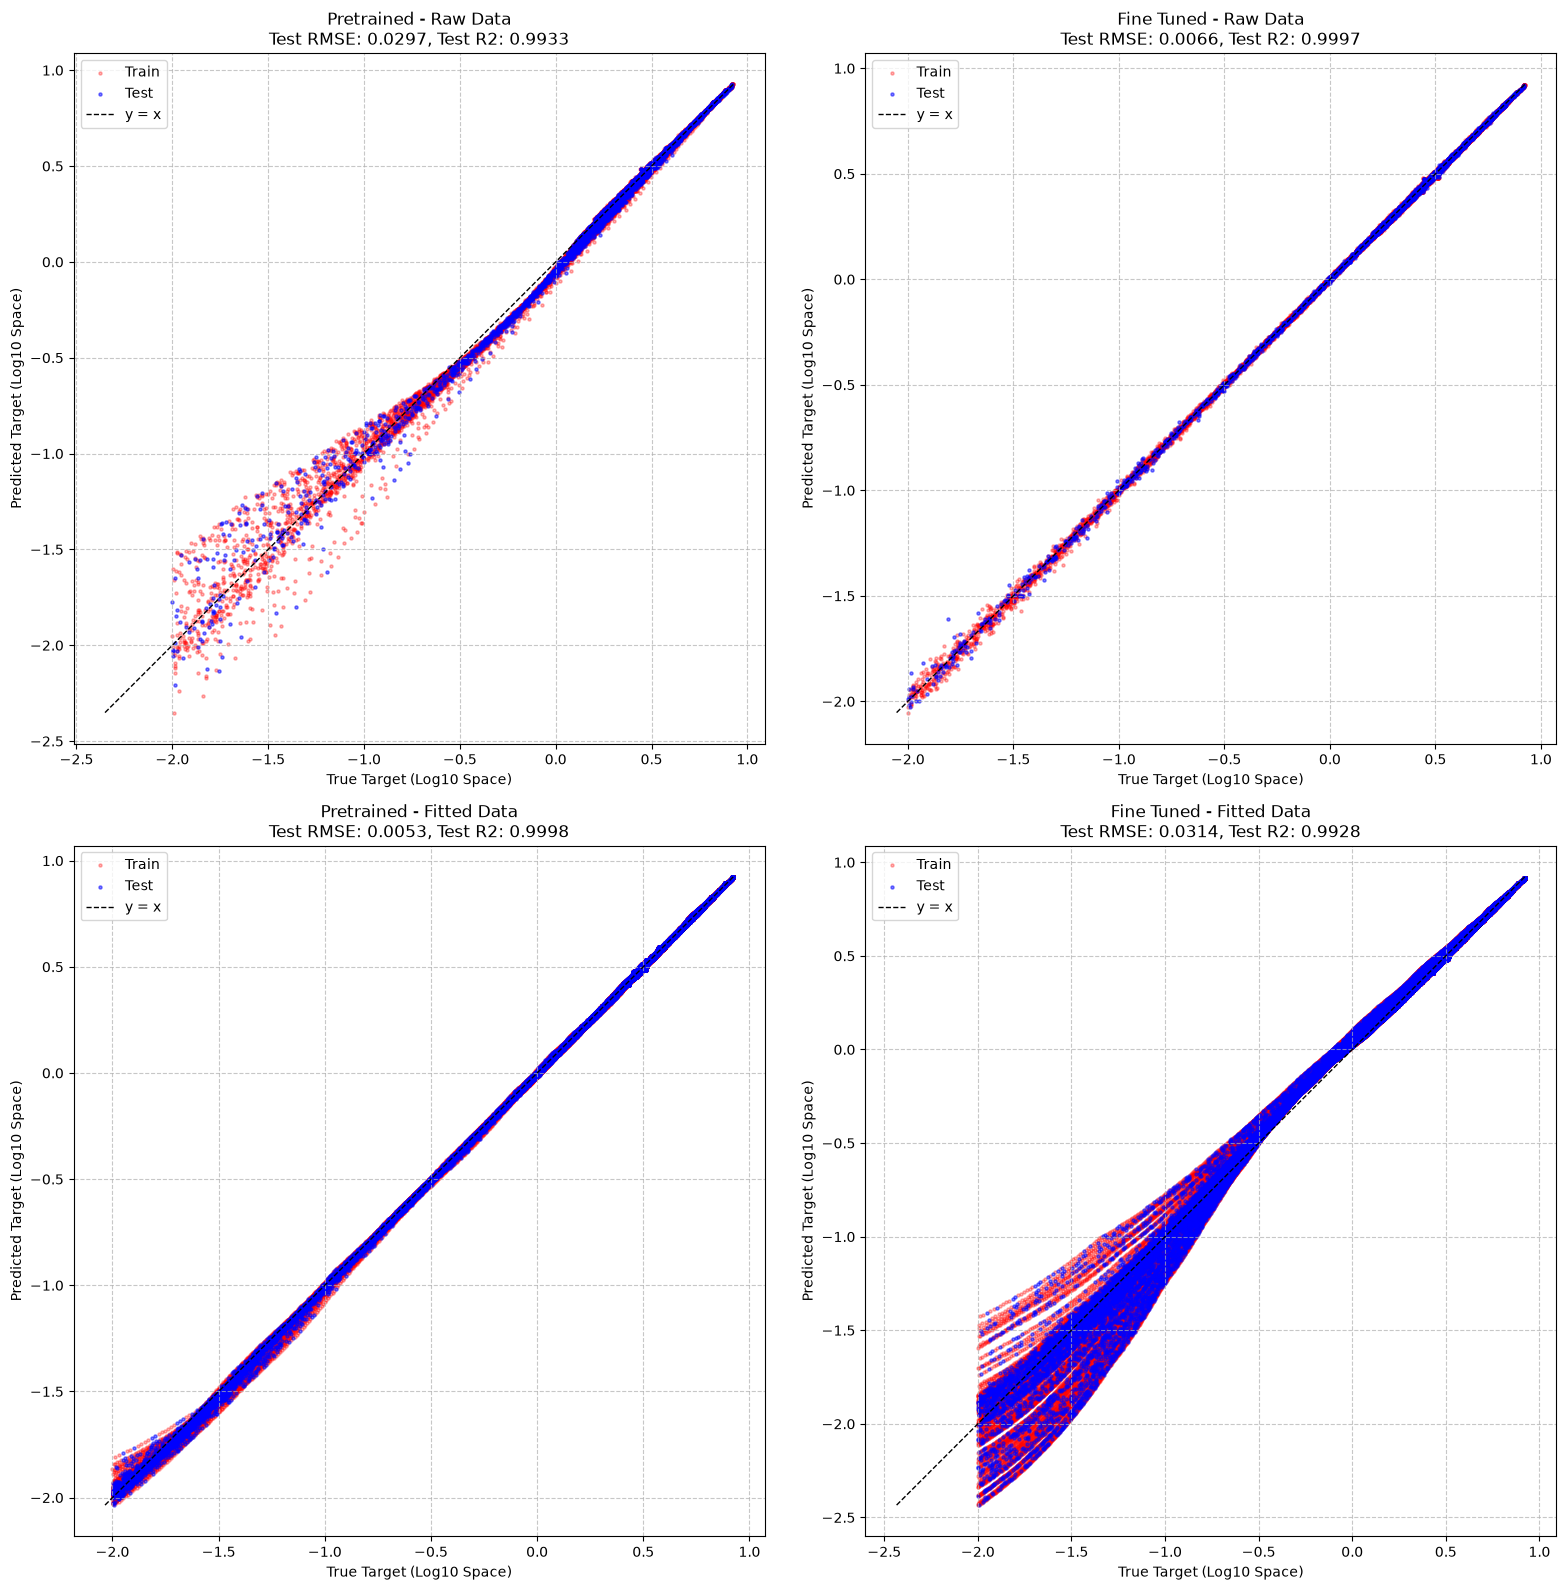

In [8]:
# Parity plots: predicted vs true (log10 space), pretrained vs fine-tuned model
def parity_panel(ax, y_train, p_train, y_test, p_test, title):
    p_train = p_train.flatten()
    p_test = p_test.flatten()
    ax.scatter(y_train, p_train, s=size, color='red', alpha=0.3, label='Train')
    ax.scatter(y_test, p_test, s=size, color='blue', alpha=0.5, label='Test')
    lo = min(y_train.min(), y_test.min(), p_train.min(), p_test.min())
    hi = max(y_train.max(), y_test.max(), p_train.max(), p_test.max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='y = x')
    rmse = np.sqrt(np.mean((y_test - p_test) ** 2))
    r2 = r2_score(y_test, p_test)
    ax.set_title(f"{title}\nTest RMSE: {rmse:.4f}, Test R2: {r2:.4f}")
    ax.set_xlabel('True Target (Log10 Space)')
    ax.set_ylabel('Predicted Target (Log10 Space)')
    ax.set_aspect('equal')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
parity_panel(axes[0, 0], yraw_selected_train, pretrained_predraw_train,
             yraw_selected_test, pretrained_predraw_test, 'Pretrained - Raw Data')
parity_panel(axes[0, 1], yraw_selected_train, fine_tuned_predraw_train,
             yraw_selected_test, fine_tuned_predraw_test, 'Fine Tuned - Raw Data')
parity_panel(axes[1, 0], yfit_selected_train, pretrained_predfit_train,
             yfit_selected_test, pretrained_predfit_test, 'Pretrained - Fitted Data')
parity_panel(axes[1, 1], yfit_selected_train, fine_tuned_predfit_train,
             yfit_selected_test, fine_tuned_predfit_test, 'Fine Tuned - Fitted Data')
plt.tight_layout()
plt.show()


Unique j1 values in raw train data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 16.]
Unique j1 values in raw  test data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 16.]
Unique j2 values in raw train data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23.]
Unique j2 values in raw  test data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23.]
Unique j1 values in raw data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 16.]
Unique j2 values in raw data: [ 0.  1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23.]
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


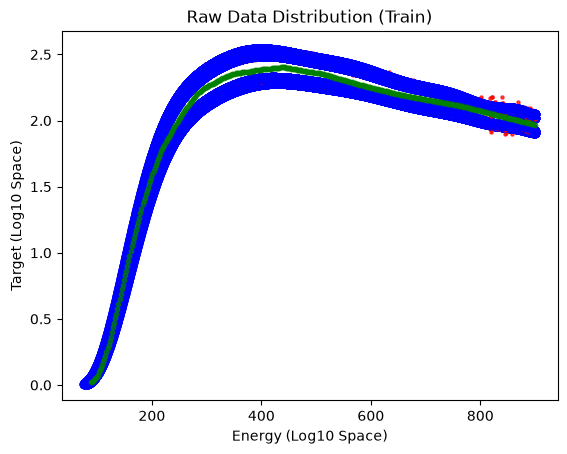

In [9]:

print("Unique j1 values in raw train data:", np.unique(Xraw_selected_train[:, 0]))
print("Unique j1 values in raw  test data:", np.unique(Xraw_selected_test[:, 0]))
print("Unique j2 values in raw train data:", np.unique(Xraw_selected_train[:, 1]))
print("Unique j2 values in raw  test data:", np.unique(Xraw_selected_test[:, 1]))

Xraw = np.concatenate((Xraw_selected_train, Xraw_selected_test), axis=0)
yraw = np.concatenate((yraw_selected_train, yraw_selected_test), axis=0)
Xfit = np.concatenate((Xfit_selected_train, Xfit_selected_test), axis=0)
yfit = np.concatenate((yfit_selected_train, yfit_selected_test), axis=0)

print("Unique j1 values in raw data:", np.unique(Xraw[:, 0]))
print("Unique j2 values in raw data:", np.unique(Xraw[:, 1]))

j1s= [1, 3]
j1pred = 2
j2s = [11, 13]
j2pred = 12
selectedindex = np.where((Xraw[:, 0] == j1s[0]) \
                         & (Xraw[:, 1] == j2s[0]))
Xraw_subset = Xraw[selectedindex]
evalues = Xraw_subset[:, 2]

X_pres = np.array([[j1pred, j2pred, e] for e in evalues])
X_pres_scaled = scalerXraw.transform(X_pres)
predictions_scaled = fine_tuned_model.predict(X_pres_scaled)
predictions = scaleryraw.inverse_transform(predictions_scaled.reshape(-1, 1))
#print(f"Predictions for (v={j1pred}, j={j2pred}) at different energies:")
#for e, pred in zip(evalues, predictions.flatten()):
#    print(f"Energy: {e:.2f}, Predicted Target: {pred:.4f}")

for j1 in j1s:
    for j2 in j2s:
        selectedindex = np.where((Xraw[:, 0] == j1) & (Xraw[:, 1] == j2))
        Xraw_subset = Xraw[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = yraw[selectedindex]
        yraw_subset = np.pow(10, yraw_subset)
        plt.scatter(eraw, yraw_subset, s=size, label="Train", color='red', alpha=0.7)
        selectedindex = np.where((Xfit[:, 0] == j1) & (Xfit[:, 1] == j2))
        Xfit_subset = Xfit[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = yfit[selectedindex]
        yfit_subset = np.pow(10, yfit_subset)
        plt.scatter(efit, yfit_subset, linewidths=1, label="Train (Fitted)", color='blue', alpha=0.7) 
plt.scatter(evalues, np.pow(10, predictions.flatten()), s=size*2, label="Predictions (v=10,j=2)+(v=0,j=30)", color='green', alpha=0.7)  
plt.xlabel('Energy (Log10 Space)')
plt.ylabel('Target (Log10 Space)')
plt.title('Raw Data Distribution (Train)')
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 295us/step


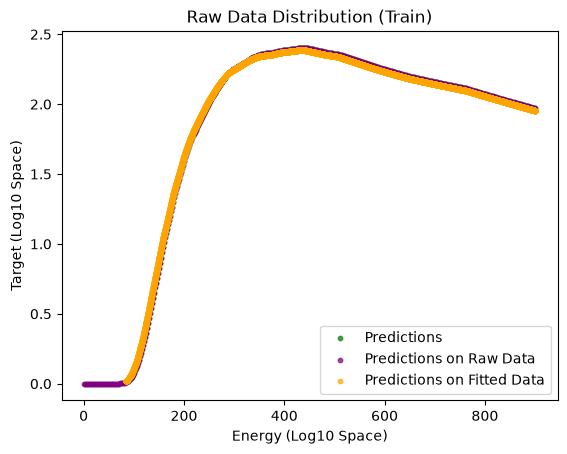

In [10]:
evaluesraw = np.load('evaluesraw.npz')['evalues']
evaluesfit = np.load('evaluesfit.npz')['evalues']

X_pres = np.array([[j1pred, j2pred, e] for e in evalues])
X_pres_scaled = scalerXraw.transform(X_pres)
predictions_scaled = fine_tuned_model.predict(X_pres_scaled)
predictions = scaleryraw.inverse_transform(predictions_scaled.reshape(-1, 1))
X_pres = np.array([[j1pred, j2pred, e] for e in evaluesraw])
X_pres_scaled = scalerXraw.transform(X_pres)
predictions_scaled = fine_tuned_model.predict(X_pres_scaled)
predictions_raw = scaleryraw.inverse_transform(predictions_scaled.reshape(-1, 1))
X_pres = np.array([[j1pred, j2pred, e] for e in evaluesfit])
X_pres_scaled = scalerXfit.transform(X_pres)
predictions_scaled = fine_tuned_model.predict(X_pres_scaled)
predictions_fit = scaleryfit.inverse_transform(predictions_scaled.reshape(-1, 1))

plt.scatter(evalues, np.pow(10, predictions.flatten()), s=size*2, label="Predictions", color='green', alpha=0.7)  
plt.scatter(evaluesraw, np.pow(10, predictions_raw.flatten()), s=size*2, label="Predictions on Raw Data", color='purple', alpha=0.7)
plt.scatter(evaluesfit, np.pow(10, predictions_fit.flatten()), s=size*2, label="Predictions on Fitted Data", color='orange', alpha=0.7)
plt.xlabel('Energy (Log10 Space)')
plt.ylabel('Target (Log10 Space)')
plt.title('Raw Data Distribution (Train)')
plt.legend()
plt.show()
